## Box-Jenkins Time Series Modeling

This notebook applies the Box-Jenkins methodology to smart meter energy data, using different configurations of ARIMA, SARIMA, and AutoARIMA models. Insights are supported with comparative plots and diagnostics. The bonus section explores SARIMAX using external variables.


## Prompts Used in This Assignment

- "Load the data and transform it into long format for user 'MAC000150'"
- "Load the weather data and match both time series"
- "Apply necessary checks and resampling for using ARIMA"
- "We will compare different ARIMA models, train ARIMA with different parameters and plot its fit overlayed on the timeseries (comparable plots) — use a plot function"
- "Now use auto_arima to get best parameters"
- "Now create a similar function to the one in ARIMA but with SARIMA"
- "Run auto_arima with seasonal"
- "Now create new function that takes weather as exo variable"
- "Try auto_arima with exo"


In [10]:
import pandas as pd

# Load block data
block = pd.read_csv('block_21.csv')

# Filter for user "MAC000150"
user_df = block[block['LCLid'] == 'MAC000150'].copy()

# Melt into long format
half_hour_cols = [f"hh_{i}" for i in range(48)]  # adjust if your columns are named like "hh_0", "hh_1", etc.
df_long = user_df.melt(id_vars=["LCLid", "day"],
                       value_vars=half_hour_cols,
                       var_name="half_hour",
                       value_name="energy_kwh")

# Parse date and half-hour index
df_long['day'] = pd.to_datetime(df_long['day'])
df_long['half_hour'] = df_long['half_hour'].str.extract(r'(\d+)').astype(int)

# Create timestamp
df_long['timestamp'] = df_long['day'] + pd.to_timedelta(df_long['half_hour'] * 30, unit='m')

# Drop missing values
df_long = df_long.dropna(subset=['energy_kwh'])

# Set timestamp as index
df_long.set_index('timestamp', inplace=True)

# Sort by index just in case
df_long = df_long.sort_index()

# Show result
df_long.head()


,LCLid,day,half_hour,energy_kwh
timestamp,,,,
2011-11-24 00:00:00,MAC000150,2011-11-24,0,0.158
2011-11-24 00:30:00,MAC000150,2011-11-24,1,0.204
2011-11-24 01:00:00,MAC000150,2011-11-24,2,0.158
2011-11-24 01:30:00,MAC000150,2011-11-24,3,0.149
2011-11-24 02:00:00,MAC000150,2011-11-24,4,0.165


In [11]:
# Load weather data
weather = pd.read_csv("weather_hourly_darksky.csv")

# Convert 'time' to datetime and set as index
weather['time'] = pd.to_datetime(weather['time'])
weather.set_index('time', inplace=True)

# Keep only temperature (or any other relevant column)
weather = weather[['temperature']]  # you can add others like 'humidity', etc.

# Resample weather to half-hour frequency to match df_long
weather_resampled = weather.resample('30min').interpolate()

# Align both datasets
combined = pd.merge(df_long[['energy_kwh']], weather_resampled,
                    left_index=True, right_index=True, how='inner')

# Rename for clarity
combined.columns = ['energy_kwh', 'temperature']

# Show result
combined.head()


,energy_kwh,temperature
2011-11-24 00:00:00,0.158,9.010
2011-11-24 00:30:00,0.204,9.000
2011-11-24 01:00:00,0.158,8.990
2011-11-24 01:30:00,0.149,8.775
2011-11-24 02:00:00,0.165,8.560


In [12]:
# Resample combined data to daily frequency
ts_daily = combined['energy_kwh'].resample('D').mean().dropna()

# Also resample temperature to daily mean (if using exogenous variables later)
temp_daily = combined['temperature'].resample('D').mean().dropna()


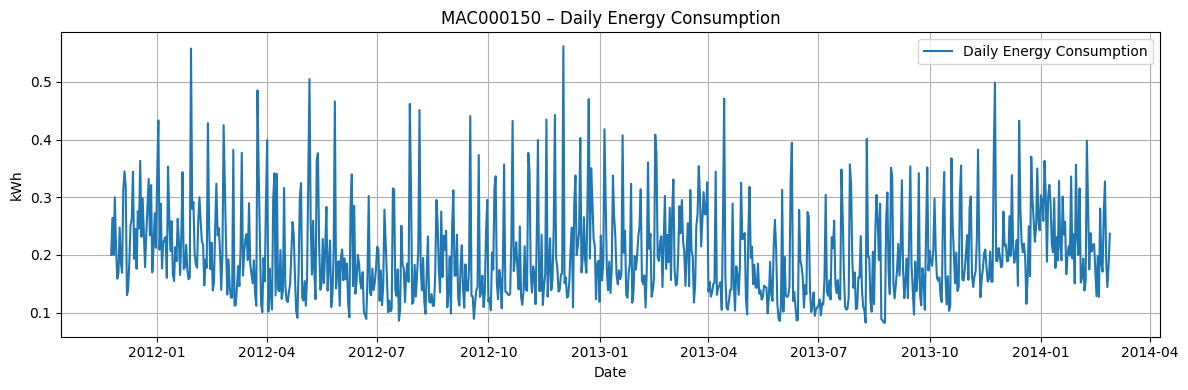

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(ts_daily, label='Daily Energy Consumption')
plt.title('MAC000150 – Daily Energy Consumption')
plt.xlabel('Date')
plt.ylabel('kWh')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series, title):
    result = adfuller(series)
    print(f"ADF Statistic for {title}: {result[0]:.3f}")
    print(f"p-value: {result[1]:.4f}")
    if result[1] < 0.05:
        print("Stationary")
    else:
        print("Not Stationary — Differencing Needed")

check_stationarity(ts_daily, "Daily Energy Consumption")


ADF Statistic for Daily Energy Consumption: -3.280
p-value: 0.0158
Stationary


In [15]:
from statsmodels.tsa.arima.model import ARIMA

def fit_and_plot_arima(series, order, label=None):
    model = ARIMA(series, order=order)
    fit = model.fit()
    pred = fit.fittedvalues

    plt.plot(series, label='Actual', color='black', linewidth=1)
    plt.plot(pred, label=f'ARIMA{order} Fit' if label is None else label, linestyle='--')
    plt.title(f'ARIMA{order} Fit on Daily Energy Consumption')
    plt.xlabel('Date')
    plt.ylabel('Energy (kWh)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"ARIMA{order} AIC: {fit.aic:.2f}")
    return fit


/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


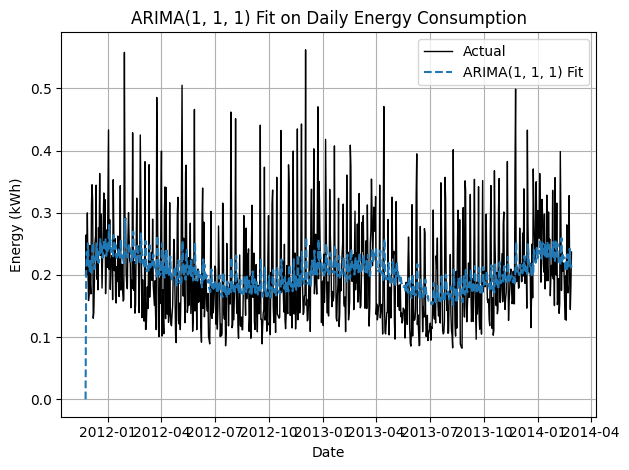

ARIMA(1, 1, 1) AIC: -1806.66


/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregres

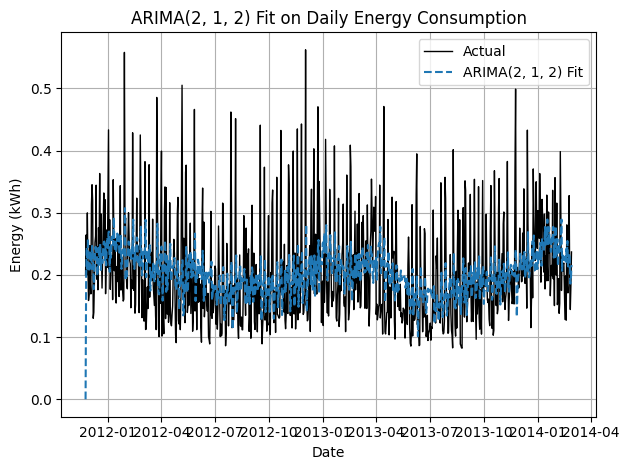

/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA(2, 1, 2) AIC: -1851.54


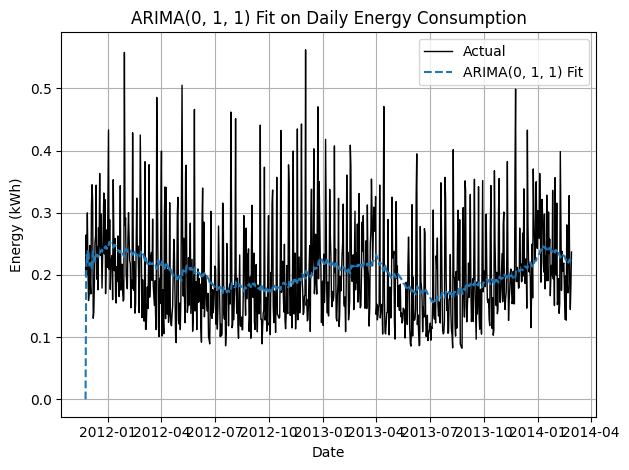

ARIMA(0, 1, 1) AIC: -1789.33


/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


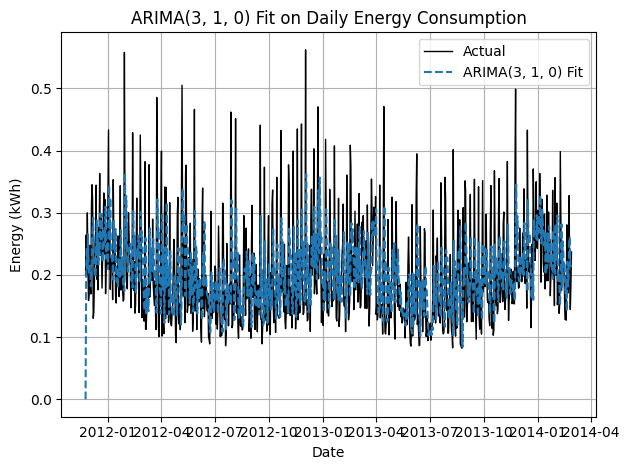

ARIMA(3, 1, 0) AIC: -1596.38


In [16]:
# Model 1: Simple ARIMA(1,1,1)
fit1 = fit_and_plot_arima(ts_daily, (1,1,1))

# Model 2: ARIMA(2,1,2)
fit2 = fit_and_plot_arima(ts_daily, (2,1,2))

# Model 3: ARIMA(0,1,1)
fit3 = fit_and_plot_arima(ts_daily, (0,1,1))

# Model 4: ARIMA(3,1,0)
fit4 = fit_and_plot_arima(ts_daily, (3,1,0))


## ARIMA Model Comparison

We compare multiple ARIMA models with different `(p,d,q)` settings to evaluate their fit and ability to capture the dynamics of daily energy consumption.

- Models tested: ARIMA(1,1,1), ARIMA(2,1,2), ARIMA(0,1,1), ARIMA(3,1,0)
- Evaluation metric: Visual overlay + AIC
- Fitted values are plotted against the actual consumption time series


In [17]:

from pmdarima import auto_arima
# AutoARIMA without seasonality first
auto_model = auto_arima(ts_daily,
                        seasonal=False,
                        stepwise=True,
                        trace=True,
                        suppress_warnings=True,
                        error_action='ignore')

# Summary and best order
print("Best ARIMA order:", auto_model.order)
auto_model.summary()


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-1813.421, Time=0.30 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-1383.298, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-1470.585, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-1787.363, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-1385.298, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-1818.460, Time=0.22 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-1812.801, Time=0.18 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-1804.682, Time=0.19 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-1814.493, Time=0.37 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-1827.186, Time=0.23 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=-1839.264, Time=0.36 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=-1824.420, Time=0.51 sec
 ARIMA(0,1,5)(0,0,0)[0] intercept   : AIC=-1843.440, Time=0.44 sec
 ARIMA(1,1,5)(0,0,0)[0] intercept   : AIC=-1839.819, Time=0.47 sec
 ARIMA(0,1,5)(0,0,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  821
Model:               SARIMAX(0, 1, 5)   Log Likelihood                 928.743
Date:                Mon, 21 Apr 2025   AIC                          -1845.485
Time:                        12:26:33   BIC                          -1817.230
Sample:                             0   HQIC                         -1834.644
                                - 821                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8286      0.033    -24.876      0.000      -0.894      -0.763
ma.L2         -0.3280      0.050     -6.547      0.000      -0.426      -0.230
ma.L3          0.0821      0.061      1.354      0.176      -0.037       0.201
ma.L4          0.0465      0.056      0.828      0.408      -0.064       0.156
ma.L5          0.0737      0.042      1.745      0.081      -0.009       0.156
sigma2         0.0061      0.000     25.025      0.000       0.006       0.007
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):               259.83
Prob(Q):                              0.90   Prob(JB):                         0.00
Heteroskedasticity (H):               0.82   Skew:                             1.15
Prob(H) (two-sided):                  0.09   Kurtosis:                         4.53
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


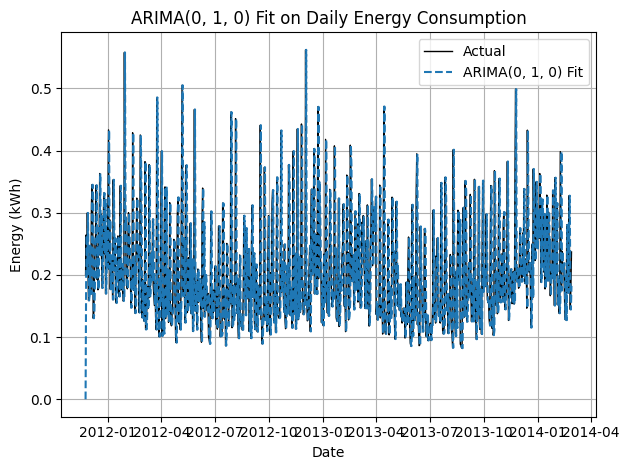

/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA paramet

ARIMA(0, 1, 0) AIC: -1385.30


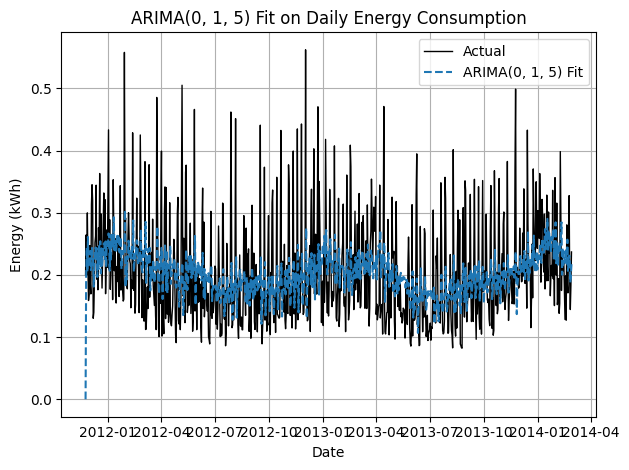

ARIMA(0, 1, 5) AIC: -1845.49


In [18]:
fit5 = fit_and_plot_arima(ts_daily, (0,1,0))
fit6 = fit_and_plot_arima(ts_daily, (0,1,5))

### Results

- lowest AIC from model 5 (0,1,0) shows clear overfitting.
- model 6 (best paramters from auto Arima) shows more resonable graph


In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fit_and_plot_sarima(series, order, seasonal_order, label=None):
    model = SARIMAX(series,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False)

    fit = model.fit(disp=False)
    fitted_vals = fit.fittedvalues

    # Plot
    plt.figure(figsize=(12, 4))
    plt.plot(series, label='Actual', color='black')
    plt.plot(fitted_vals, label=label or f'SARIMA{order}x{seasonal_order}', linestyle='--')
    plt.title(f'SARIMA Fit: {order}x{seasonal_order}')
    plt.xlabel('Date')
    plt.ylabel('Energy (kWh)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"SARIMA{order}x{seasonal_order} AIC: {fit.aic:.2f}")
    return fit


/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


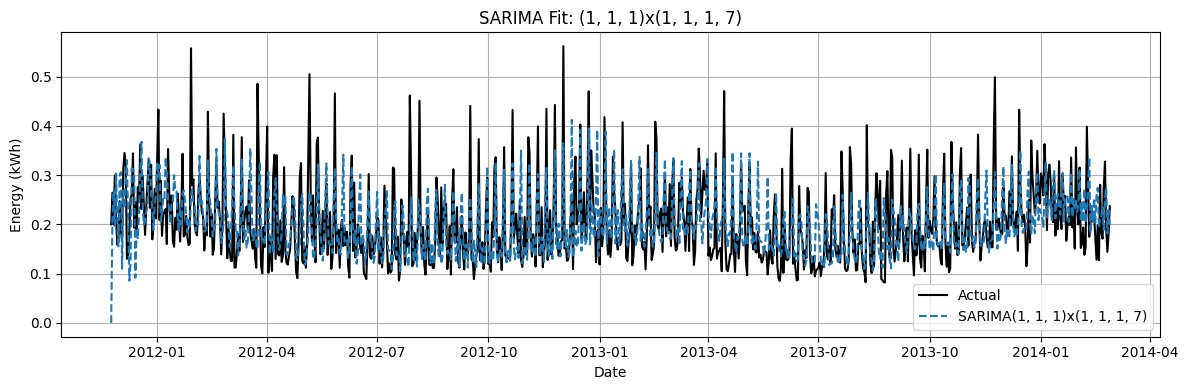

SARIMA(1, 1, 1)x(1, 1, 1, 7) AIC: -1991.80


/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


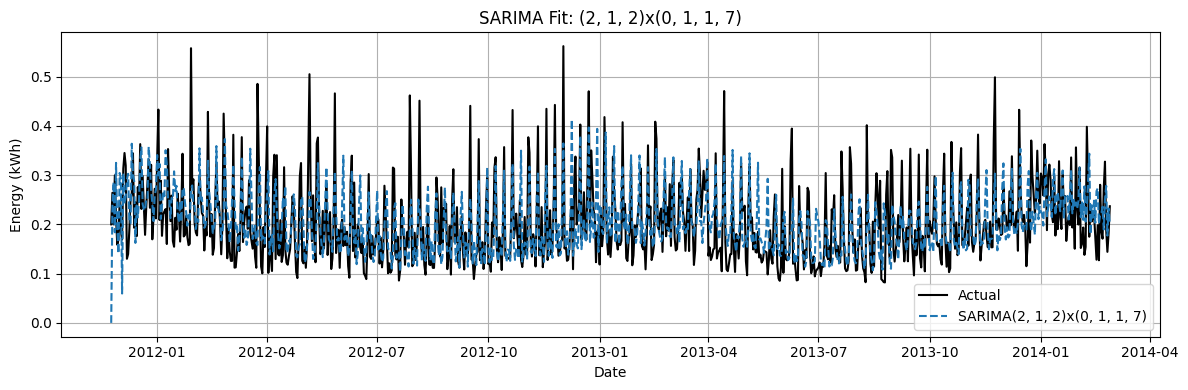

SARIMA(2, 1, 2)x(0, 1, 1, 7) AIC: -1990.80


/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


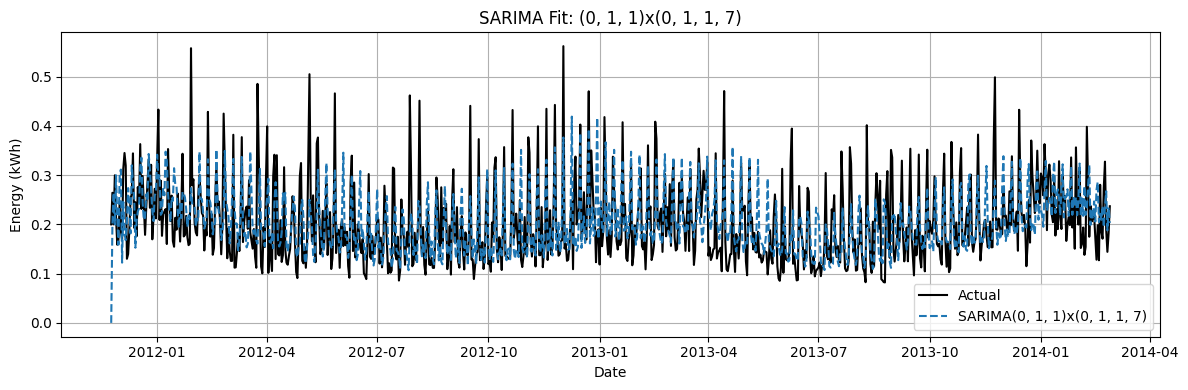

SARIMA(0, 1, 1)x(0, 1, 1, 7) AIC: -1990.64


/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


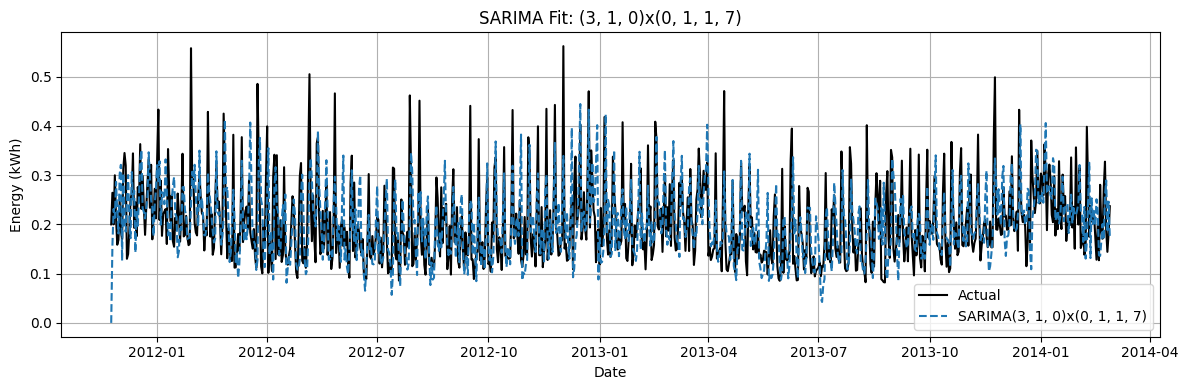

SARIMA(3, 1, 0)x(0, 1, 1, 7) AIC: -1832.14


/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


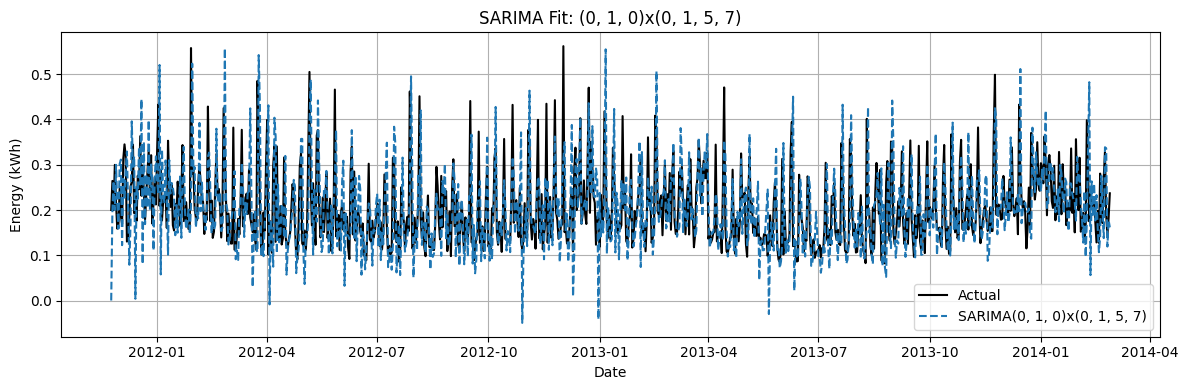

SARIMA(0, 1, 0)x(0, 1, 5, 7) AIC: -1489.87


/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


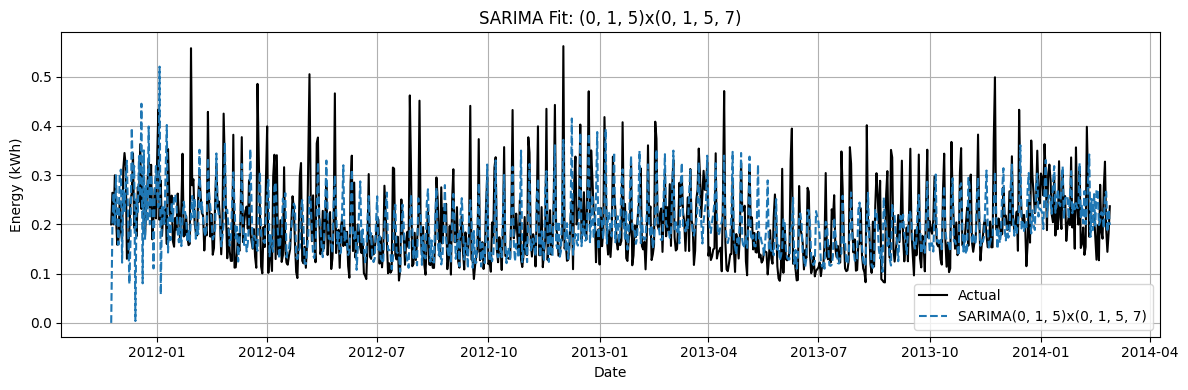

SARIMA(0, 1, 5)x(0, 1, 5, 7) AIC: -1908.95


In [21]:

fit_sarima1 = fit_and_plot_sarima(ts_daily, order=(1,1,1), seasonal_order=(1,1,1,7))
fit_sarima2 = fit_and_plot_sarima(ts_daily, order=(2,1,2), seasonal_order=(0,1,1,7))
fit_sarima3 = fit_and_plot_sarima(ts_daily, order=(0,1,1), seasonal_order=(0,1,1,7))
fit_sarima4 = fit_and_plot_sarima(ts_daily, order=(3,1,0), seasonal_order=(0,1,1,7))
fit_sarima5 = fit_and_plot_sarima(ts_daily, order=(0,1,0), seasonal_order=(0,1,5,7))
fit_sarima6 = fit_and_plot_sarima(ts_daily, order=(0,1,5), seasonal_order=(0,1,5,7))

## SARIMA Model Comparison

SARIMA models were trained with various seasonal configurations to capture both trend and weekly seasonality.

Each model’s in-sample fit is plotted over the actual series, and AIC is used to help evaluate model quality.


In [22]:
auto_sarima = auto_arima(
    ts_daily,
    seasonal=True,
    m=7,  # 7 days = weekly seasonality
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action='ignore'
)

# Display summary and best params
print("Best SARIMA Order:", auto_sarima.order)
print("Best Seasonal Order:", auto_sarima.seasonal_order)
auto_sarima.summary()


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=1.53 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=-1383.298, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=-1610.377, Time=0.20 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=-1867.931, Time=0.43 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=-1385.298, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=-1787.363, Time=0.11 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=-2049.472, Time=0.65 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=-1920.367, Time=0.35 sec
 ARIMA(0,1,1)(2,0,1)[7] intercept   : AIC=inf, Time=0.99 sec
 ARIMA(0,1,1)(1,0,2)[7] intercept   : AIC=-2049.317, Time=1.47 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=-1928.295, Time=0.92 sec
 ARIMA(0,1,1)(2,0,0)[7] intercept   : AIC=-1992.435, Time=0.76 sec
 ARIMA(0,1,1)(2,0,2)[7] intercept   : AIC=-2038.693, Time=1.61 sec
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=-1592.369, Time=0.41 sec
 ARIMA(1,1,1)(1,0,1)[7] interce

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                  821
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 7)   Log Likelihood                1029.736
Date:                           Mon, 21 Apr 2025   AIC                          -2049.472
Time:                                   13:06:04   BIC                          -2025.925
Sample:                                        0   HQIC                         -2040.437
                                           - 821                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept  -6.555e-06    1.3e-05     -0.503      0.615   -3.21e-05     1.9e-05
ma.L1         -0.9823      0.008   -124.699      0.000      -0.998      -0.967
ar.S.L7        0.9441      0.015     64.037      0.000       0.915       0.973
ma.S.L7       -0.7402      0.030    -25.079      0.000      -0.798      -0.682
sigma2         0.0047      0.000     23.853      0.000       0.004       0.005
===================================================================================
Ljung-Box (L1) (Q):                   8.96   Jarque-Bera (JB):               218.16
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.86   Skew:                             0.87
Prob(H) (two-sided):                  0.21   Kurtosis:                         4.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


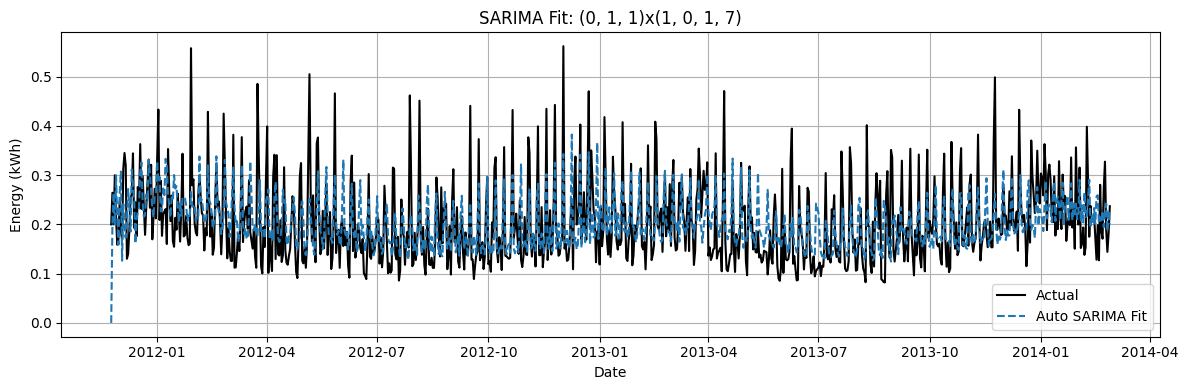

SARIMA(0, 1, 1)x(1, 0, 1, 7) AIC: -2021.15


In [23]:
fit_sarima_auto = fit_and_plot_sarima(
    ts_daily,
    order=auto_sarima.order,
    seasonal_order=auto_sarima.seasonal_order,
    label='Auto SARIMA Fit'
)

## 🔍 Seasonal AutoARIMA

Using `auto_arima` with `seasonal=True`, we automatically identified the best SARIMA configuration based on AIC optimization.

- Best order: ARIMA(0,1,1)
- Best seasonal order: (1,0,1,7) → weekly pattern

This model captures both short-term dynamics and recurring weekly seasonality in the daily energy consumption series.


In [24]:
def fit_and_plot_sarimax(series, exog, order, seasonal_order, label=None):
    """
    Fits SARIMAX model with exogenous variables and plots in-sample predictions.
    
    Parameters:
        series (pd.Series): target time series
        exog (pd.Series or DataFrame): exogenous variable(s), aligned with index
        order (tuple): ARIMA order (p,d,q)
        seasonal_order (tuple): seasonal order (P,D,Q,s)
        label (str): custom label for plot legend (optional)
    
    Returns:
        fitted model
    """
    model = SARIMAX(
        series,
        exog=exog,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fit = model.fit(disp=False)
    fitted_vals = fit.fittedvalues

    # Plot
    plt.figure(figsize=(12, 4))
    plt.plot(series, label='Actual', color='black')
    plt.plot(fitted_vals, label=label or f'SARIMAX{order}x{seasonal_order}', linestyle='--', color='green')
    plt.title(f'SARIMAX Fit with Exogenous Variable: {order}x{seasonal_order}')
    plt.xlabel('Date')
    plt.ylabel('Energy (kWh)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"SARIMAX{order}x{seasonal_order} AIC: {fit.aic:.2f}")
    return fit


/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


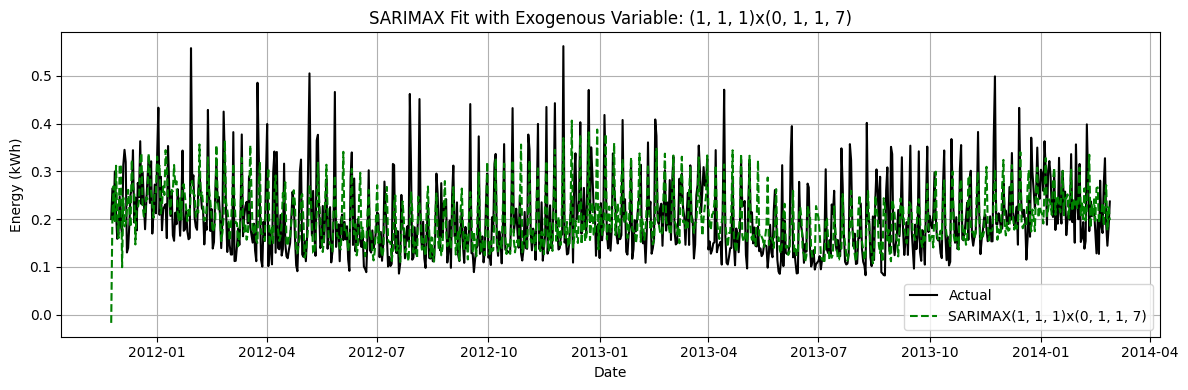

SARIMAX(1, 1, 1)x(0, 1, 1, 7) AIC: -2000.85


In [25]:

temp_daily = combined['temperature'].resample('D').mean().dropna()
aligned = pd.concat([ts_daily, temp_daily], axis=1).dropna()
aligned.columns = ['energy_kwh', 'temperature']

# Run SARIMAX
fit_sarimax = fit_and_plot_sarimax(
    aligned['energy_kwh'],
    exog=aligned[['temperature']],
    order=(1, 1, 1),
    seasonal_order=(0, 1, 1, 7)
)


In [26]:
y = aligned['energy_kwh']
X = aligned[['temperature']]  # must be DataFrame

In [27]:
auto_sarimax = auto_arima(
    y,
    exogenous=X,
    seasonal=True,
    m=7,  # Weekly seasonality
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action='ignore'
)

# Display model info
print("Best order:", auto_sarimax.order)
print("Best seasonal order:", auto_sarimax.seasonal_order)
auto_sarimax.summary()


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=1.59 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=-1383.298, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=-1610.377, Time=0.21 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=-1867.931, Time=0.40 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=-1385.298, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=-1787.363, Time=0.11 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=-2049.472, Time=0.62 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=-1920.367, Time=0.36 sec
 ARIMA(0,1,1)(2,0,1)[7] intercept   : AIC=inf, Time=0.97 sec
 ARIMA(0,1,1)(1,0,2)[7] intercept   : AIC=-2049.317, Time=1.43 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=-1928.295, Time=0.92 sec
 ARIMA(0,1,1)(2,0,0)[7] intercept   : AIC=-1992.435, Time=0.69 sec
 ARIMA(0,1,1)(2,0,2)[7] intercept   : AIC=-2038.693, Time=1.61 sec
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=-1592.369, Time=0.40 sec
 ARIMA(1,1,1)(1,0,1)[7] interce

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                  821
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 7)   Log Likelihood                1029.736
Date:                           Mon, 21 Apr 2025   AIC                          -2049.472
Time:                                   13:11:17   BIC                          -2025.925
Sample:                                        0   HQIC                         -2040.437
                                           - 821                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept  -6.555e-06    1.3e-05     -0.503      0.615   -3.21e-05     1.9e-05
ma.L1         -0.9823      0.008   -124.699      0.000      -0.998      -0.967
ar.S.L7        0.9441      0.015     64.037      0.000       0.915       0.973
ma.S.L7       -0.7402      0.030    -25.079      0.000      -0.798      -0.682
sigma2         0.0047      0.000     23.853      0.000       0.004       0.005
===================================================================================
Ljung-Box (L1) (Q):                   8.96   Jarque-Bera (JB):               218.16
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.86   Skew:                             0.87
Prob(H) (two-sided):                  0.21   Kurtosis:                         4.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


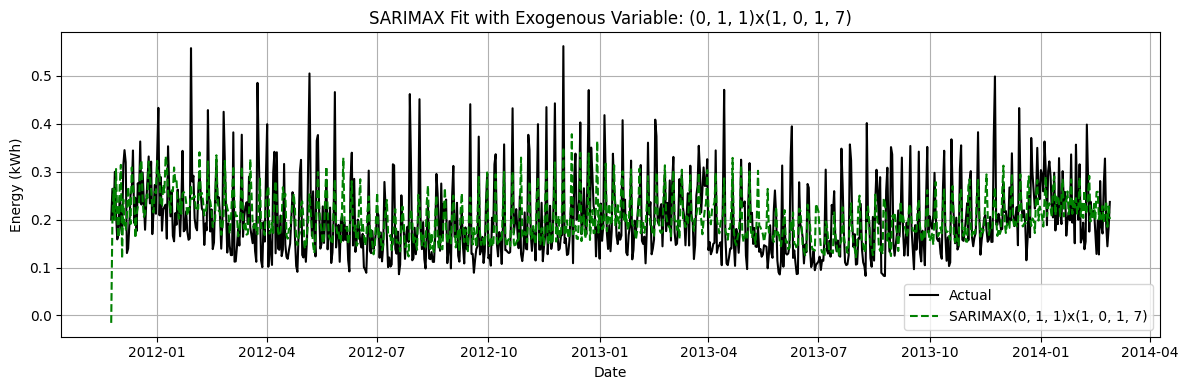

SARIMAX(0, 1, 1)x(1, 0, 1, 7) AIC: -2023.69


In [28]:
best_order = auto_sarimax.order
best_seasonal = auto_sarimax.seasonal_order

# Fit and plot SARIMAX using best parameters
fit_sarimax = fit_and_plot_sarimax(
    y,
    exog=X,
    order=best_order,
    seasonal_order=best_seasonal
)


/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohamedkorayem/anaconda3/envs/ITI/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


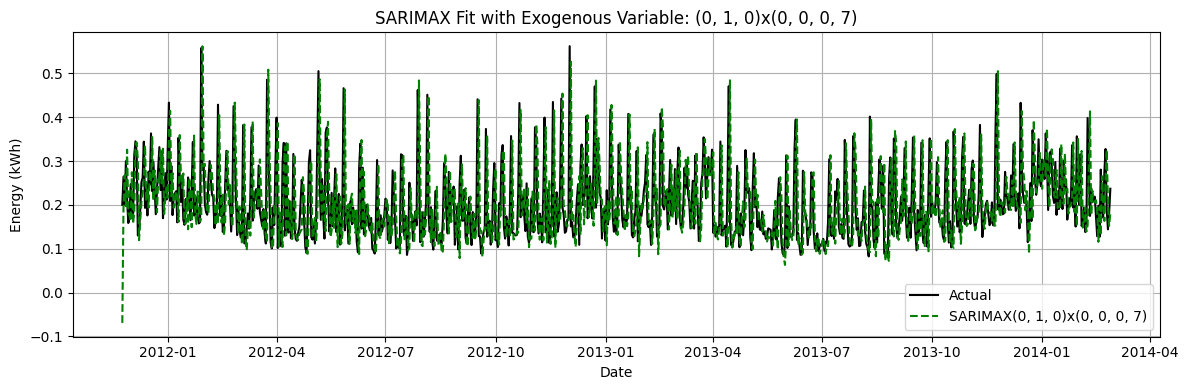

SARIMAX(0, 1, 0)x(0, 0, 0, 7) AIC: -1393.82


In [30]:

# Fit and plot SARIMAX using best parameters
fit_sarimax = fit_and_plot_sarimax(
    y,
    exog=X,
    order=(0,1,0),
    seasonal_order=(0,0,0,7)
)


## AutoSARIMAX (with Temperature as Exogenous)

We used `auto_arima` with temperature as an external regressor to automatically determine the best SARIMAX configuration.

- Selected model: SARIMAX(p,d,q)x(P,D,Q,7)
- This allows the model to capture both weekly seasonality and weather-dependent energy usage patterns.


## Final Summary: Box-Jenkins Modeling of Daily Energy Consumption

In this notebook, we applied the Box-Jenkins methodology to model daily energy consumption for user `MAC000150` using ARIMA, SARIMA, and SARIMAX models.

### Key Steps:

- The time series was preprocessed, resampled to daily frequency, and checked for stationarity using ADF tests.
- Multiple **ARIMA models** with different `(p,d,q)` values were trained and visually compared.
- We then extended our analysis to **SARIMA models**, incorporating weekly seasonality `(P,D,Q,7)` and comparing their in-sample fit.
- To automate parameter selection, we used **AutoARIMA** with and without seasonal components.
- Finally, we introduced **temperature as an exogenous variable** and trained **SARIMAX models**, including an AutoSARIMAX run to determine the best seasonal + exogenous configuration.

### Model Selection Insight:

While **AIC** is commonly used to select the best model, a lower AIC score does **not always guarantee better generalization** — it may indicate **overfitting** in some cases.

AutoARIMA is valuable because it **balances model complexity and performance**, often selecting a model that performs well without overfitting.
